In [1]:
import logging
logging.getLogger("fontTools").setLevel(logging.WARNING)

import os
_r = os.path.abspath(".")
while _r != os.path.dirname(_r) and not os.path.exists(os.path.join(_r, ".notebooks_root")):
    _r = os.path.dirname(_r)
os.chdir(_r if os.path.exists(os.path.join(_r, ".notebooks_root")) else "/oak/stanford/groups/quake/mmantri/group.quake/tabula_longread/notebooks")  # cd to notebooks/ root (marked .notebooks_root); relocation-proof

import popv
import scanpy as sc
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import anndata as ad
from collections import Counter
from scipy.sparse import csr_matrix 
import gc
import os, sys
import glob
gc.enable()

/home/groups/quake/mmantri/miniconda3/envs/popv/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3699: UserWarning: Pretrained models on huggingface are trained with Python 3.11. Detected Python {sys.version.split()[:2]} will not load these models.
  exec(code_obj, self.user_global_ns, self.user_ns)
/home/groups/quake/mmantri/miniconda3/envs/popv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/groups/quake/mmantri/miniconda3/envs/popv/lib/python3.11/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv
Loading faiss with AVX2 support.
Successfully loaded faiss with AVX2 support.
2026-07-17 10:29:46.961396: I tensorflow/core/platform/cpu_feature_guard.cc:210] This

In [2]:
# Load gene-level PacBio long-read data (recollapsed, merged across all tissues)
h5ad_path = "./../pacbio/h5ads/all_samples_pacbio_recollapsed_raw_counts_genes_bc_anndata_mincounts500.h5ad"
adata = sc.read_h5ad(h5ad_path)
print(adata)
print(f"\nVar index (gene symbols): {adata.var_names[:5].tolist()}")
print(f"Obs columns: {list(adata.obs.columns)}")
print(f"\nSample (tissue ID) distribution:")
print(adata.obs["tube_id"].value_counts())

AnnData object with n_obs × n_vars = 293501 × 69580
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'tube_id', 'n_counts', 'donor', 'tissue', 'tube_label', 'LR_library_id', 'SR_sample_id'
    var: 'gene_ids', 'gene_id', 'gene_name', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

Var index (gene symbols): ['7SK', '7SK-1', '7SK-2', '7SK-3', 'A1BG']
Obs columns: ['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'tube_id', 'n_counts', 'donor', 'tissue', 'tube_label', 'LR_library_id', 'SR_sample_id']

Sample (tissue ID) distribution:
tube_id
T29    12719
T6     12078
T34    11802
T41    10042
T6

#popV Cell Type Annotation of PacBio Long-Read Gene Data (Tissue-by-Tissue)
#Using Tabula Sapiens pretrained models from HuggingFace with "fast" prediction mode.
Annotates gene-level PacBio recollapsed data (from `merge_all_tissues_genes.ipynb`) using tissue-specific Tabula Sapiens popV models.

In [3]:
# Check unique tissue values after mapping
print("Unique samples:", sorted(adata.obs["tube_id"].dropna().unique().tolist()))
print(f"\nNumber of sample: {adata.obs['tube_id'].nunique()}")

Unique samples: ['T10', 'T12', 'T13', 'T14', 'T15', 'T16', 'T17', 'T19', 'T20', 'T21', 'T22', 'T23', 'T25', 'T28', 'T29', 'T3', 'T30', 'T31', 'T32', 'T33', 'T34', 'T35', 'T37', 'T38', 'T39', 'T4', 'T40', 'T41', 'T42', 'T43', 'T44', 'T45', 'T46', 'T47', 'T48', 'T49', 'T5', 'T50', 'T51', 'T52', 'T53', 'T54', 'T55', 'T56', 'T57', 'T58', 'T59', 'T6', 'T60', 'T61', 'T62', 'T63', 'T64', 'T65', 'T66', 'T68', 'T69', 'T75', 'T8', 'T9']

Number of sample: 60


In [4]:
# Check unique tissue values after mapping
print("Unique tissues:", sorted(adata.obs["tissue"].dropna().unique().tolist()))
print(f"\nNumber of tissues: {adata.obs['tissue'].nunique()}")

Unique tissues: ['Bladder', 'Blood', 'Bone_Marrow', 'Ear', 'Fat', 'Heart', 'Kidney', 'Large_Intestine', 'Liver', 'Lung', 'Lymph_Node', 'Muscle', 'Ovary', 'Pancreas', 'Prostate', 'Salivary_Gland', 'Skin', 'Small_Intestine', 'Spleen', 'Stomach', 'Testis', 'Thymus', 'Tongue', 'Trachea', 'Uterus', 'Vasculature']

Number of tissues: 26


In [5]:
# Build sample -> tissue -> popV model mapping
# The popV HuggingFace models follow the pattern: popV/tabula_sapiens_{Tissue_Name}
sample_to_tissue = adata.obs.groupby("tube_id")["tissue"].first().to_dict()

print("Sample -> Tissue -> popV model mapping:")
for sample in sorted(sample_to_tissue.keys()):
    tissue = sample_to_tissue[sample]
    model = f"popV/tabula_sapiens_{tissue}"
    n = (adata.obs["tube_id"] == sample).sum()
    print(f"  {sample} ({n} cells) -> {tissue} -> {model}")

Sample -> Tissue -> popV model mapping:
  T10 (5644 cells) -> Lung -> popV/tabula_sapiens_Lung
  T12 (4104 cells) -> Pancreas -> popV/tabula_sapiens_Pancreas
  T13 (296 cells) -> Tongue -> popV/tabula_sapiens_Tongue
  T14 (3876 cells) -> Blood -> popV/tabula_sapiens_Blood
  T15 (3451 cells) -> Bladder -> popV/tabula_sapiens_Bladder
  T16 (7140 cells) -> Testis -> popV/tabula_sapiens_Testis
  T17 (6062 cells) -> Thymus -> popV/tabula_sapiens_Thymus
  T19 (3076 cells) -> Small_Intestine -> popV/tabula_sapiens_Small_Intestine
  T20 (269 cells) -> Liver -> popV/tabula_sapiens_Liver
  T21 (83 cells) -> Prostate -> popV/tabula_sapiens_Prostate
  T22 (95 cells) -> Vasculature -> popV/tabula_sapiens_Vasculature
  T23 (2282 cells) -> Large_Intestine -> popV/tabula_sapiens_Large_Intestine
  T25 (7250 cells) -> Trachea -> popV/tabula_sapiens_Trachea
  T28 (3222 cells) -> Kidney -> popV/tabula_sapiens_Kidney
  T29 (12719 cells) -> Ovary -> popV/tabula_sapiens_Ovary
  T3 (7288 cells) -> Ear -> popV

In [6]:
from popv.hub import HubModel

# Output directory for popV results
save_dir = "./../pacbio/popv_results/all_samples_recollapsed/"
os.makedirs(save_dir, exist_ok=True)

# Verify var index has gene symbols (needed for popV matching)
print(f"Var index examples: {adata.var_names[:10].tolist()}")
print(f"Total genes: {adata.n_vars}")

Var index examples: ['7SK', '7SK-1', '7SK-2', '7SK-3', 'A1BG', 'A1BG+ENSG00000283103', 'A1BG+ZNF497', 'A1BG-AS1', 'A1BG-AS1+ENSG00000268049', 'A1BG-AS1+ENSG00000279611']
Total genes: 69580


In [7]:
# Run popV annotation sample-by-sample
results_list = []
failed_samples = []

for sample in sorted(sample_to_tissue.keys()):

    tissue_name = sample_to_tissue[sample]
    model_name = f"popV/tabula_sapiens_{tissue_name}"

    sample_mask = adata.obs["tube_id"] == sample
    n_cells = sample_mask.sum()

    if n_cells == 0:
        print(f"Skipping {sample}: no cells found")
        continue

    print(f"\n{'='*60}")
    print(f"Processing {sample} ({tissue_name}, {n_cells} cells) with model {model_name}")
    print(f"{'='*60}")

    try:
        # Subset query data for this sample
        query_adata = adata[sample_mask].copy()

        # PacBio gene h5ad already has raw counts in .X
        # Ensure X is a sparse matrix
        if not isinstance(query_adata.X, csr_matrix):
            query_adata.X = csr_matrix(query_adata.X)

        # Remove extra layers/obsm/obsp to avoid conflicts during concat
        query_adata.layers.clear()
        query_adata.obsm.clear()
        query_adata.obsp.clear()
        query_adata.uns.clear()

        # Load pretrained model from HuggingFace
        hub_model = HubModel.pull_from_huggingface_hub(model_name)

        # Run annotation in fast mode
        # var_names are already gene symbols, so use "feature_name"
        hub_model.annotate_data(
            query_adata,
            prediction_mode="fast",
            gene_symbols="feature_name",
            save_path=os.path.join(save_dir, sample),
        )

        # Store the annotated obs (cell-level predictions)
        results_list.append(query_adata.obs)

        print(f"Completed {sample}. Top predicted cell types:")
        if "popv_prediction" in query_adata.obs.columns:
            print(query_adata.obs["popv_prediction"].value_counts().head(10))

        # Free memory
        del query_adata, hub_model
        gc.collect()

    except Exception as e:
        print(f"ERROR processing {sample} ({tissue_name}): {e}")
        failed_samples.append(sample)
        gc.collect()
        continue

print(f"\n{'='*60}")
print(f"Annotation complete.")
if failed_samples:
    print(f"Failed samples: {failed_samples}")
else:
    print("All samples processed successfully.")


Processing T10 (Lung, 5644 cells) with model popV/tabula_sapiens_Lung


HTTP Request: GET https://huggingface.co/api/models/popV/tabula_sapiens_Lung/revision/main "HTTP/1.1 200 OK"
Fetching 22 files:   0%|          | 0/22 [00:00<?, ?it/s]HTTP Request: HEAD https://huggingface.co/popV/tabula_sapiens_Lung/resolve/3abdff6289e4311f2fa11a4ef333af7859b36e37/accuracies.json "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/popV/tabula_sapiens_Lung/resolve/3abdff6289e4311f2fa11a4ef333af7859b36e37/README.md "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/popV/tabula_sapiens_Lung/resolve/3abdff6289e4311f2fa11a4ef333af7859b36e37/OnClass.meta "HTTP/1.1 302 Found"
HTTP Request: HEAD https://huggingface.co/popV/tabula_sapiens_Lung/resolve/3abdff6289e4311f2fa11a4ef333af7859b36e37/OnClass.npz "HTTP/1.1 302 Found"
HTTP Request: HEAD https://huggingface.co/popV/tabula_sapiens_Lung/resolve/3abdff6289e4311f2fa11a4ef333af7859b36e37/OnClass.data-00000-of-00001 "HTTP/1.1 302 Found"
HTTP Request: HEAD https://huggingface.co/po

INFO     Found 97.8% reference vars in query data.                                                                 


The following cells will be excluded from annotation because they have low expression:Index(['CGAATACACTCCTTCG-1_T10', 'CTCACGTACCCGCACA-1_T10',
       'AAAGGTAACGGGTATG-1_T10', 'TCCTAGGCTCTAACTG-1_T10',
       'AGTGGGCCTCATGATC-1_T10', 'ACCTCGGGAAAGAGGA-1_T10',
       'TTTCTCCACATGAATG-1_T10', 'TACTTTGTGTGGGAGT-1_T10',
       'GCAAGGAACTGATGTC-1_T10', 'TAGAGGGTGGCACTCG-1_T10',
       'GCTTTCGTGGGGACAT-1_T10'],
      dtype='object').
  0%|          | 0/6 [00:00<?, ?it/s]Integrating data with scvi


INFO     File                                                                                                      
         /tmp/huggingface/hub/models--popV--tabula_sapiens_Lung/snapshots/3abdff6289e4311f2fa11a4ef333af7859b36e37/
         scvi/model.pt already downloaded                                                                          


...

Epoch 1/1: 100%|██████████| 1/1 [00:03<00:00,  3.51s/it, v_num=1, train_loss=561]

Saving scanvi label prediction to adata.obs["popv_scanvi_prediction"]



INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


Saving UMAP of BBKNN results to adata.obsm["X_umap_scanvi_popv"]
 33%|███▎      | 2/6 [00:17<00:35,  8.99s/it]Computing support vector machine. Storing prediction in adata.obs["popv_svm_prediction"]
Computing XGboost classifier. Storing prediction in adata.obs["popv_xgboost_prediction"]
 83%|████████▎ | 5/6 [00:21<00:03,  3.46s/it]Saving celltypist results to adata.obs["popv_celltypist_prediction"]
🔬 Input data has 2549 cells and 4000 genes
🔗 Matching reference genes in the model
🧬 4000 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
100%|██████████| 6/6 [00:22<00:00,  3.71s/it]
Using predictions ['popv_knn_on_scvi_prediction', 'popv_scanvi_prediction', 'popv_svm_prediction', 'popv_xgboost_prediction', 'popv_onclass_prediction', 'popv_celltypist_prediction'] for PopV consensus
Predictions saved to ./../pacbio/popv_results/all_samples_recollapsed/T9/popv_output/predictions.csv


Completed T9. Top predicted cell types:

Annotation complete.
All samples processed successfully.


In [8]:
# Reload predictions from saved CSVs (useful if restarting from here)
all_popv_predictions = dict()
for sample in sorted(sample_to_tissue.keys()):
    pred_path = os.path.join(save_dir, sample, "popv_output", "predictions.csv")
    if os.path.exists(pred_path):
        print(f"Loading {sample}")
        df = pd.read_csv(pred_path, index_col=0)
        all_popv_predictions[sample] = df
    else:
        print(f"WARNING: predictions not found for {sample} at {pred_path}")

all_results = pd.concat(all_popv_predictions.values(), axis=0)
print(f"\nCombined predictions: {all_results.shape}")
all_results.head()

Loading T10
Loading T12
Loading T13
Loading T14
Loading T15
Loading T16
Loading T17
Loading T19
Loading T20
Loading T21
Loading T22
Loading T23
Loading T25
Loading T28
Loading T29
Loading T3
Loading T30
Loading T31
Loading T32
Loading T33
Loading T34
Loading T35
Loading T37
Loading T38
Loading T39
Loading T4
Loading T40
Loading T41
Loading T42
Loading T43
Loading T44
Loading T45
Loading T46
Loading T47
Loading T48
Loading T49
Loading T5
Loading T50
Loading T51
Loading T52
Loading T53
Loading T54
Loading T55
Loading T56
Loading T57
Loading T58
Loading T59
Loading T6
Loading T60
Loading T61
Loading T62
Loading T63
Loading T64
Loading T65
Loading T66
Loading T68
Loading T69
Loading T75
Loading T8
Loading T9

Combined predictions: (291931, 11)


,popv_knn_on_scvi_prediction,popv_scanvi_prediction,popv_svm_prediction,popv_xgboost_prediction,popv_onclass_prediction,popv_celltypist_prediction,popv_prediction,popv_prediction_score,popv_majority_vote_prediction,popv_majority_vote_score,popv_parent
AGGAGTCGACCGCATG-1_T10,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,neutrophil,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,5,pulmonary alveolar type 2 cell,5,epithelial cell of lung
TCTGTATACCACGCCA-1_T10,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,6,pulmonary alveolar type 2 cell,6,epithelial cell of lung
ACCTATACTTCCTTCG-1_T10,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,6,pulmonary alveolar type 2 cell,6,epithelial cell of lung
TCGTTGCACCCACGTG-1_T10,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,6,pulmonary alveolar type 2 cell,6,epithelial cell of lung
GATCTAGACTCTTGAG-1_T10,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,pulmonary alveolar type 2 cell,6,pulmonary alveolar type 2 cell,6,epithelial cell of lung


In [9]:
# Add popV results to the original adata object
adata.obs = adata.obs.join(all_results)

n_annotated = adata.obs["popv_prediction"].notna().sum()
print(f"Annotated: {n_annotated} / {adata.n_obs} ({n_annotated/adata.n_obs:.1%})")

Annotated: 291931 / 293501 (99.5%)


In [10]:
# Summary of popV predictions
if "popv_prediction" in adata.obs.columns:
    print("popV predicted cell types across all tissues:")
    print(adata.obs["popv_prediction"].value_counts())

    print(f"\n\nPredictions per tissue:")
    for tissue in sorted(adata.obs["tissue"].dropna().unique()):
        t_mask = adata.obs["tissue"] == tissue
        n_types = adata.obs.loc[t_mask, "popv_prediction"].nunique()
        print(f"  {tissue}: {t_mask.sum()} cells, {n_types} cell types")

popV predicted cell types across all tissues:
popv_prediction
fibroblast                                27170
stromal cell of ovary                     25819
macrophage                                19614
B cell                                    13742
CD8-positive, alpha-beta T cell           12003
                                          ...  
microvascular endothelial cell                1
neuro-medullary thymic epithelial cell        1
epithelial cell of large intestine            1
myeloid leukocyte                             1
ionocyte                                      1
Name: count, Length: 158, dtype: int64


Predictions per tissue:
  Bladder: 12740 cells, 19 cell types
  Blood: 24641 cells, 19 cell types
  Bone_Marrow: 5143 cells, 21 cell types
  Ear: 10698 cells, 13 cell types
  Fat: 17232 cells, 24 cell types
  Heart: 5401 cells, 15 cell types
  Kidney: 6871 cells, 7 cell types
  Large_Intestine: 7177 cells, 29 cell types
  Liver: 7466 cells, 22 cell types
  Lung: 1374

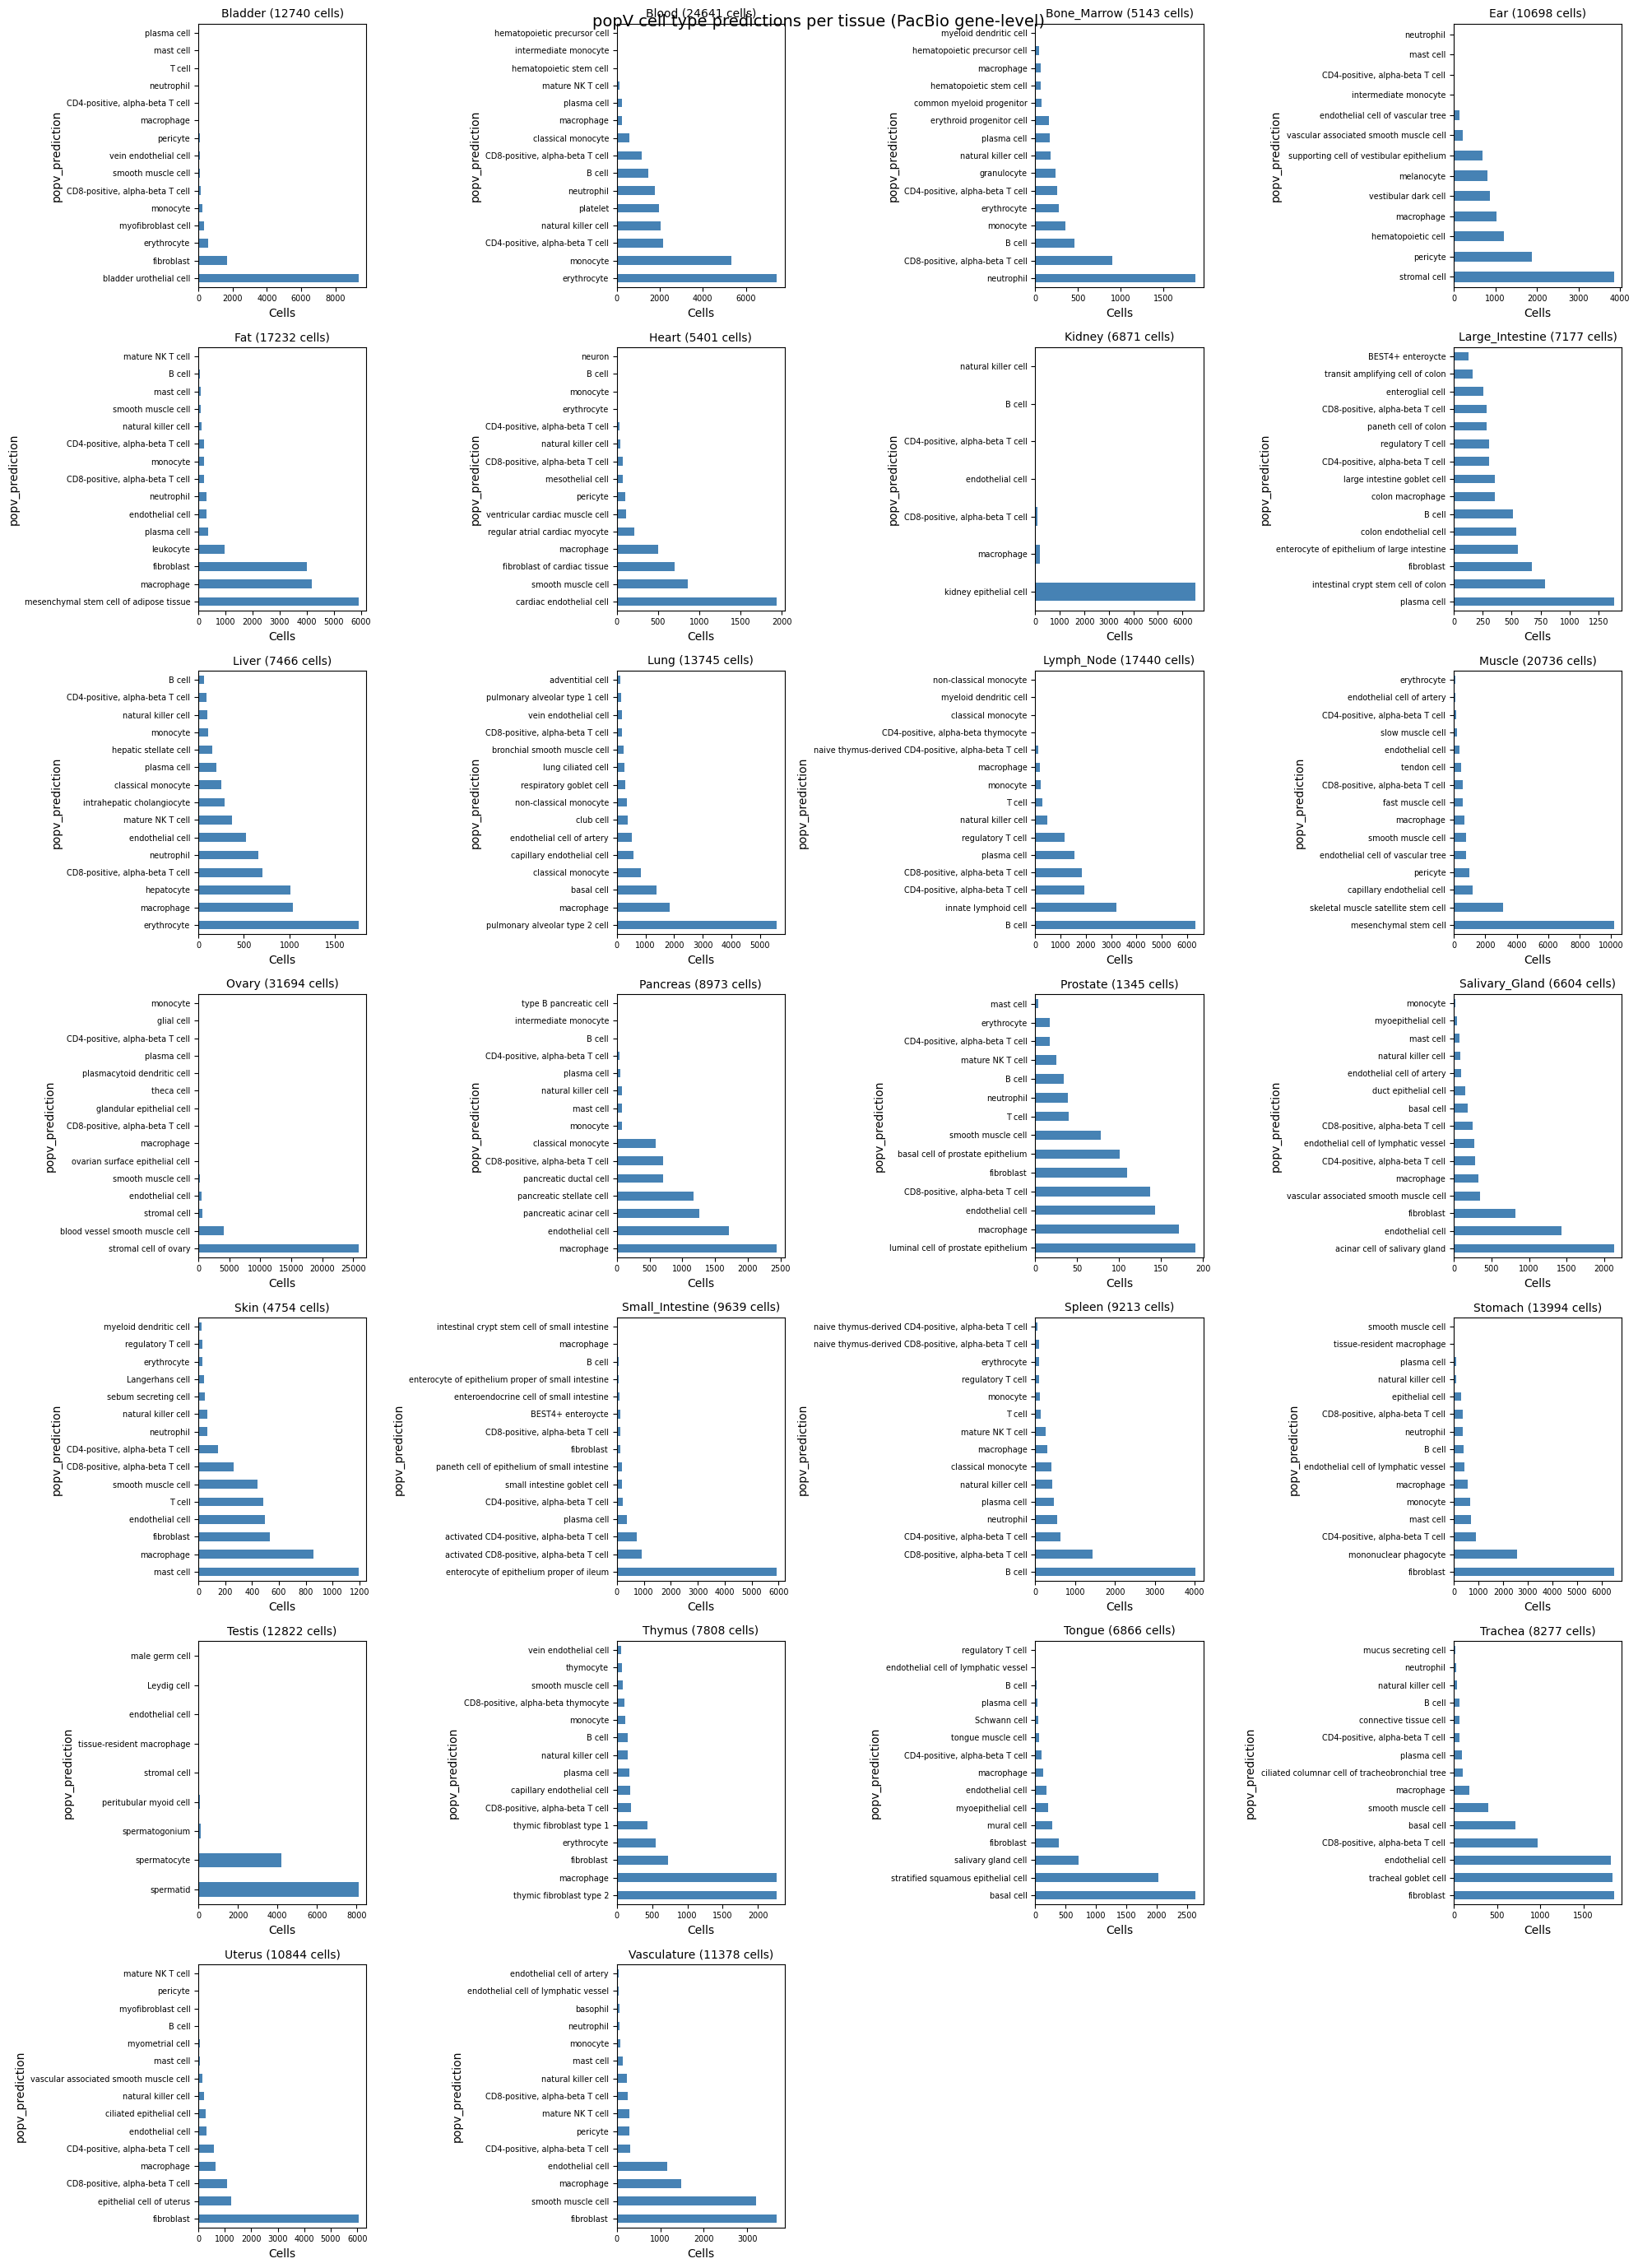

In [11]:
# Per-tissue cell type prediction barplots
n_tissues = adata.obs["tissue"].nunique()
ncols = 4
nrows = int(np.ceil(n_tissues / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for idx, tissue in enumerate(sorted(adata.obs["tissue"].dropna().unique())):
    ax = axes[idx]
    t_mask = adata.obs["tissue"] == tissue
    adata.obs.loc[t_mask, "popv_prediction"].value_counts().head(15).plot(
        kind="barh", ax=ax, color="steelblue"
    )
    ax.set_title(f"{tissue} ({t_mask.sum()} cells)", fontsize=10)
    ax.set_xlabel("Cells")
    ax.tick_params(labelsize=7)

for idx in range(n_tissues, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("popV cell type predictions per tissue (PacBio gene-level)", fontsize=14)
plt.tight_layout()
plt.show()

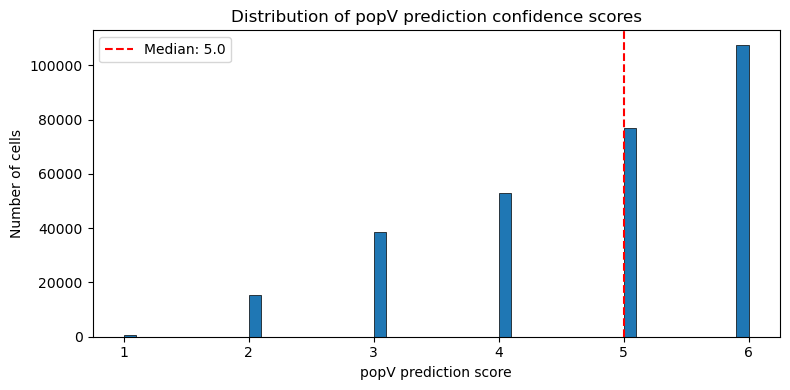

In [12]:
# popV prediction score distribution
if "popv_prediction_score" in adata.obs.columns:
    scores = pd.to_numeric(adata.obs["popv_prediction_score"], errors="coerce").dropna()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(scores, bins=50, edgecolor="black", linewidth=0.5)
    ax.set_xlabel("popV prediction score")
    ax.set_ylabel("Number of cells")
    ax.set_title("Distribution of popV prediction confidence scores")
    ax.axvline(scores.median(), color="red", linestyle="--",
               label=f"Median: {scores.median():.1f}")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("popv_prediction_score column not found")

In [13]:
# Save the predictions CSV (used by downstream analysis notebooks)
os.makedirs("./../csvs", exist_ok=True)
predictions_csv_path = "./../csvs/all_samples_recollapsed_popv_predictions_df.csv"

# Save only popV-related columns
popv_cols = [c for c in adata.obs.columns if "popv" in c.lower()]
popv_cols_plus = popv_cols + ["tissue", "Sample"]
save_cols = [c for c in popv_cols_plus if c in adata.obs.columns]
adata.obs[save_cols].to_csv(predictions_csv_path)
print(f"Saved popV predictions to {predictions_csv_path}")
print(f"Columns: {save_cols}")
print(f"Shape: {adata.obs[save_cols].shape}")

# # Also save the full annotated h5ad
# output_h5ad_path = "./../pacbio/h5ads/all_tissues_recollapsed_raw_counts_genes_bc_anndata_mincounts500_popv_annotated.h5ad"
# adata.write_h5ad(output_h5ad_path)
# print(f"\nSaved annotated h5ad to {output_h5ad_path}")

Saved popV predictions to ./../csvs/all_samples_recollapsed_popv_predictions_df.csv
Columns: ['popv_knn_on_scvi_prediction', 'popv_scanvi_prediction', 'popv_svm_prediction', 'popv_xgboost_prediction', 'popv_onclass_prediction', 'popv_celltypist_prediction', 'popv_prediction', 'popv_prediction_score', 'popv_majority_vote_prediction', 'popv_majority_vote_score', 'popv_parent', 'tissue']
Shape: (293501, 12)


In [14]:
print("Done. Outputs:")
print(f"  1. Per-sample popV results: {save_dir}/{{sample}}/popv_output/predictions.csv")
print(f"  2. Combined predictions CSV: {predictions_csv_path}")
# print(f"  3. Annotated h5ad: {output_h5ad_path}")

Done. Outputs:
  1. Per-sample popV results: ./../pacbio/popv_results/all_samples_recollapsed//{sample}/popv_output/predictions.csv
  2. Combined predictions CSV: ./../csvs/all_samples_recollapsed_popv_predictions_df.csv
